In [119]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import warnings
warnings.filterwarnings('ignore')

In [2]:
housing = fetch_california_housing(as_frame=True)

In [3]:
df = housing.frame

In [4]:
x =  housing.data
y = housing.target

1(a) Load the Dataset
Load the California Housing dataset as a Pandas DataFrame.
Display:
1. The first five observations;  
2. The dimensions of the dataset;  
3. The names of all variables

In [5]:
#The first five observations
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
#The dimensions of the dataset
df.shape

(20640, 9)

In [7]:
#The names of all the variables
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

1(b) Data Inspection
Examine the dataset and report:
1. The data type of each variable;  
2. The number of missing values in each variable;  
3. The number of duplicated observations;  
4. Descriptive statistics for all variables;  
5. Any variables containing unusually large or small values.  

In [8]:
#The data type of each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
#The number of missing values in each variable
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [10]:
#The number of duplicated observations
df.duplicated().sum()

np.int64(0)

In [11]:
#Descriptive statistics for all variables;
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [12]:
#Any variables containing unusually large or small values
def check_outliers(df):
    outliers_dict = {}
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_dict[col] = [outliers.shape[0]]
    return pd.DataFrame(data=outliers_dict.values(), index=outliers_dict.keys(), columns=['Number of Outliers'])

check_outliers(df)

,Number of Outliers
MedInc,681
HouseAge,0
AveRooms,511
AveBedrms,1424
Population,1196
AveOccup,711
Latitude,0
Longitude,0
MedHouseVal,1071


1(c) Exploratory Data Analysis
Produce the following:
1. A histogram of MedHouseVal;  
2. A correlation matrix containing all predictors and the target;  
3. A heatmap of the correlation matrix;  
4. At least two scatter plots showing the relationship between selected predictors and
MedHouseVal.  

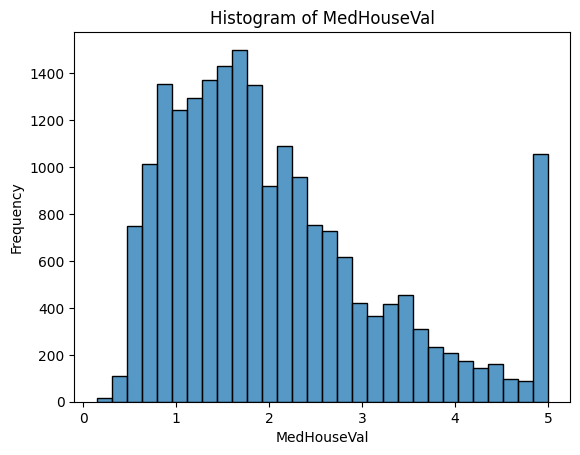

In [13]:
#A histogram of MedHouseVal
sns.histplot(df['MedHouseVal'], bins=30)
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')
plt.title('Histogram of MedHouseVal')
plt.show()

In [14]:
#A correlation matrix containing all predictors and the target
corr = df.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


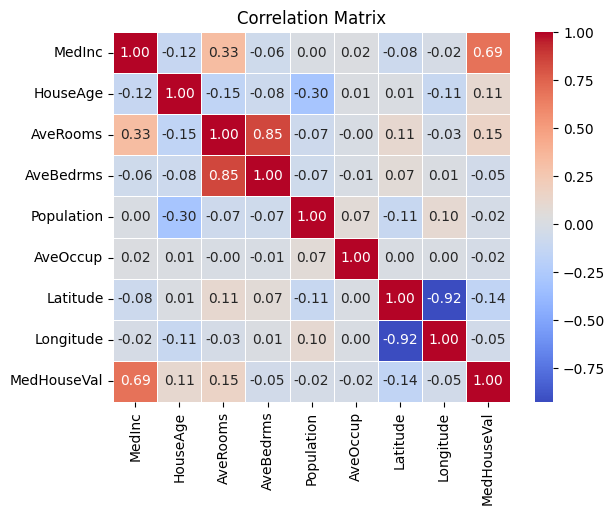

In [15]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

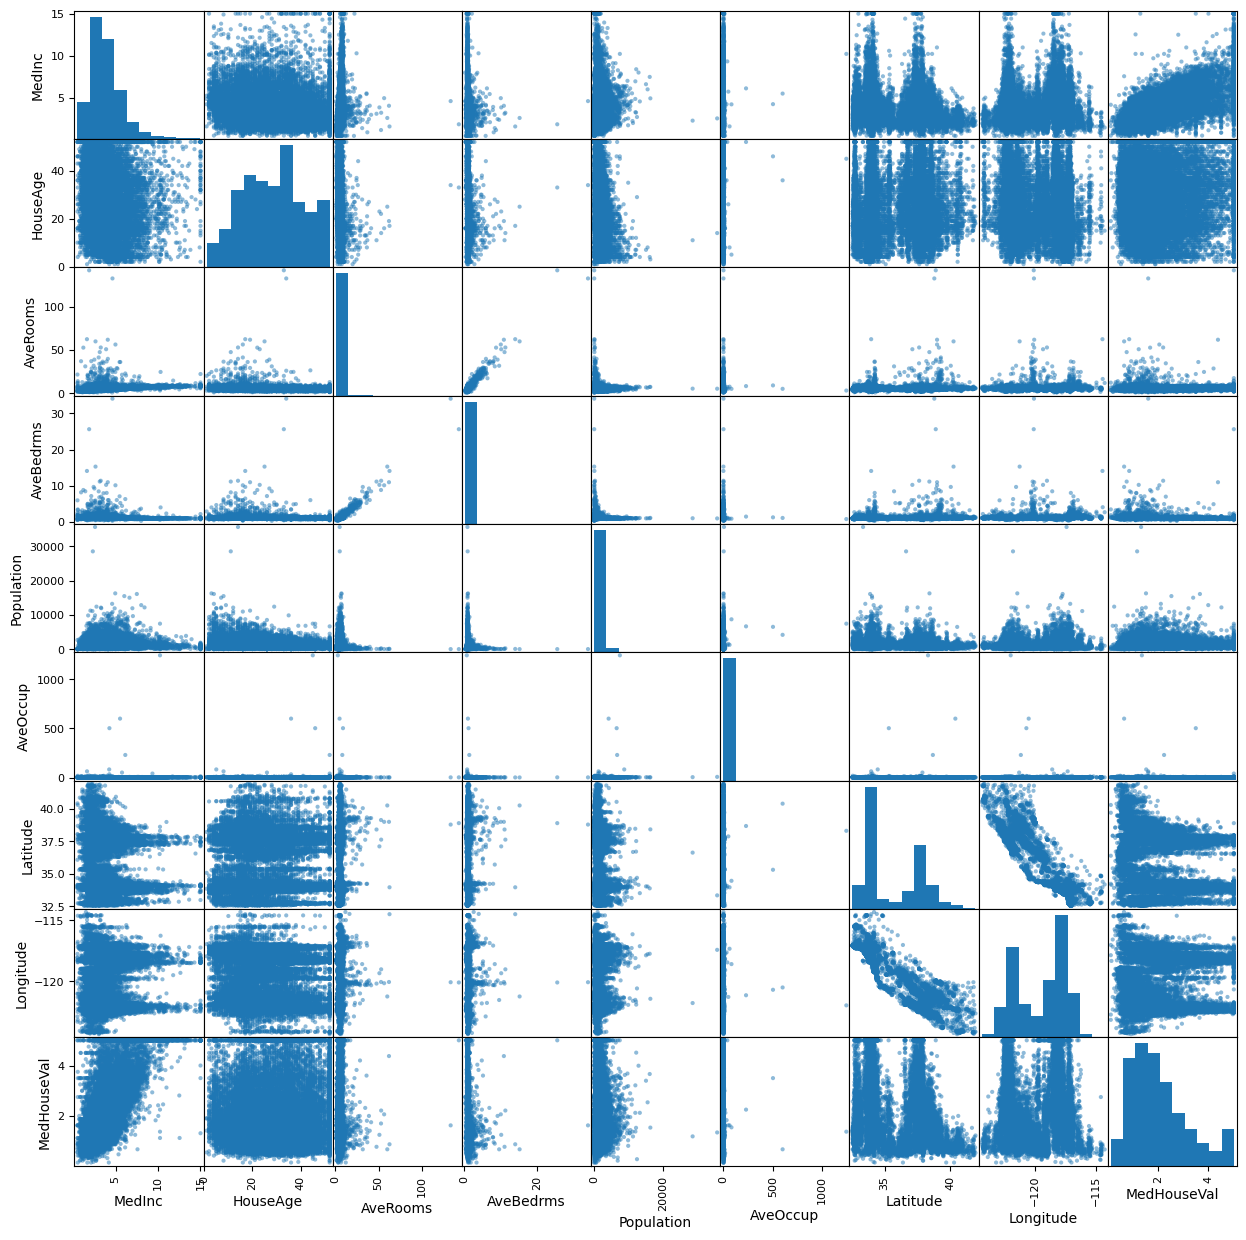

In [16]:
#At least two scatter plots showing the relationship between selected predictors and MedHouseVal
scatter_matrix = pd.plotting.scatter_matrix(df, figsize=(15, 15))
plt.show()


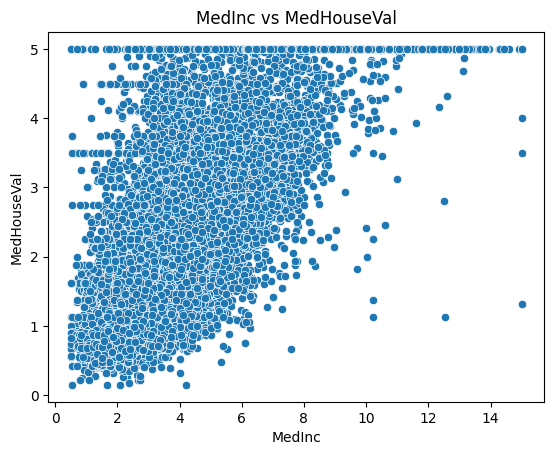

In [17]:
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)
plt.title('MedInc vs MedHouseVal')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.show()

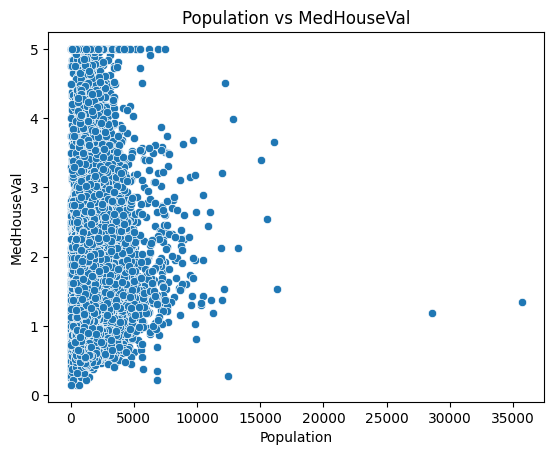

In [18]:
sns.scatterplot(x='Population', y='MedHouseVal', data=df)
plt.title('Population vs MedHouseVal')
plt.xlabel('Population')
plt.ylabel('MedHouseVal')
plt.show()

1(d) Feature Encoding and scaling
Perform a feature encoding on categorical features and scaling on numerical features.

In [19]:
x, y = df.drop('MedHouseVal', axis=1), df['MedHouseVal']
x_mean, x_std = x.mean(axis=0), x.std(axis=0)
x_scaled = (x - x_mean) / x_std
x_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344709,0.982119,0.628544,-0.153754,-0.974405,-0.049595,1.052523,-1.327803
1,2.332181,-0.607004,0.327033,-0.263329,0.861418,-0.092510,1.043159,-1.322812
2,1.782656,1.856137,1.155592,-0.049015,-0.820757,-0.025842,1.038478,-1.332794
3,0.932945,1.856137,0.156962,-0.049832,-0.766010,-0.050328,1.038478,-1.337785
4,-0.012881,1.856137,0.344702,-0.032905,-0.759828,-0.085614,1.038478,-1.337785


Question 2: Multiple Linear Regression Using a Random Split

2(a) Train-Test Split
Split the dataset into:
• 80% training data;  
• 20% testing data.  
Use: random_state=42

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)


2(b) Model Fitting
Fit a Multiple Linear Regression model using all eight predictor variables.
Use: from sklearn.linear_model import LinearRegression
Train the model only on the training dataset.

In [21]:
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)

LinearRegression()

2(c) Model Evaluation
Generate predictions for both the training and testing sets.
Calculate and report:
1. Training 𝑅2;  
2. Testing 𝑅2;  
3. Train Mean Squared Error;  
4. Test Mean Squared Error;  
5. Train Root Mean Squared Error;  
6. Test Root Mean Squared Error;  
7. Train Mean Absolute Error.  
8. Test Mean Absolute Error.

In [22]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    summary = {
        'Train': [train_r2, train_mse, train_rmse, train_mae],
        'Test': [test_r2, test_mse, test_rmse, test_mae]
    }
    return pd.DataFrame(data=summary, index =['R_squared', 'MSE', 'RMSE', 'MAE'])


In [23]:

evaluate_model(lin_model, x_train, y_train, x_test, y_test)

,Train,Test
R_squared,0.612551,0.575788
MSE,0.517933,0.555892
RMSE,0.719676,0.745581
MAE,0.528628,0.533200


Based on the result, the deviations in the train and test prediction error are minimal. Therefore the model is generalising well

Question 3: Five-Fold Cross-Validation

3(a) Cross-Validation Strategy
Create a five-fold cross-validation procedure using:
from sklearn.model_selection import KFold
cv = KFold(
n_splits=5,
shuffle=True,
random_state=42
)
Explain why shuffling and a fixed random state are useful.

In [24]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

Shuffling is important to ensure that each fold is representative of the entire dataset. If the dataset has any inherent order (e.g., time-series data, or data sorted by a particular feature), not shuffling could lead to biased training and validation sets.
Setting random_state to a specific integer (like 42) ensures that the shuffling process is reproducible. If you run the KFold split multiple times with the same random_state, you will always get the exact same division of data into training and validation folds

3(b) Cross-Validation Implementation
Evaluate the Linear Regression model using cross_validate. Use the following scoring
measure:
scoring = {
"mse": "neg_mean_squared_error"
}
Convert the negative MSE values returned by scikit-learn into positive values before
interpreting them.

In [25]:
cross_val_score = cross_validate(lin_model, x_scaled, y, cv=cv, scoring = {"mse": "neg_mean_squared_error"})

In [26]:
cross_mean_err = -cross_val_score['test_mse'].mean()
pd.DataFrame({'cross_mse': [cross_mean_err], 'single_mse': [0.517933]}, index=['MSE'])

,cross_mse,single_mse
MSE,0.530572,0.517933


Question 4: Ridge Regression Using GridSearchCV

4(a) Build a Ridge Pipeline
Create a pipeline containing:
1. StandardScaler;  
2. Ridge.  
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

4(b) Hyperparameter Tuning
Use GridSearchCV with five-fold cross-validation and negative MSE as the scoring measure.
Search over:
ridge_grid = {
"model__alpha": [
  0.0001,
  0.001,
  0.01,
  0.1,
  1,
  10,
  100,
  1000
  ]
}

In [28]:
#get a new x,y that is not scaled
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
params_grid = {
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
grid_search = GridSearchCV(estimator=ridge_pipeline, param_grid=params_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
                                          1000]},
             scoring='neg_mean_squared_error')

In [29]:
optimal_alpha = grid_search.best_params_['ridge__alpha']
best_score = -grid_search.best_score_
print(f"Optimal alpha: {optimal_alpha}")
print(f"Best score: {best_score}")

Optimal alpha: 0.0001
Best score: 0.5192652011775267


4(c) Model Evaluation
Use the optimal Ridge model to predict the test data.
Calculate:
1. Training 𝑅2;  
2. Testing 𝑅2;  
3. Train Mean Squared Error;  
4. Test Mean Squared Error;  
5. Train Root Mean Squared Error;  
6. Test Root Mean Squared Error;  
7. Train Mean Absolute Error.  
8. Test Mean Absolute Error.  

In [30]:
evaluate_model(grid_search.best_estimator_, x_train, y_train, x_test, y_test)

,Train,Test
R_squared,0.612551,0.575788
MSE,0.517933,0.555892
RMSE,0.719676,0.745581
MAE,0.528628,0.533200


In [31]:
ridge_model_coefficients = grid_search.best_estimator_.named_steps['ridge'].coef_
ridge_model_intercept = grid_search.best_estimator_.named_steps['ridge'].intercept_

print("Ridge Model Coefficients:")
print(ridge_model_coefficients)
print("\nLinear Model Coefficient:")
print(lin_model.coef_)

Ridge Model Coefficients:
[ 0.85438303  0.12254625 -0.29441011  0.33925947 -0.00230772 -0.0408291
 -0.8969288  -0.8698417 ]

Linear Model Coefficient:
[ 0.85240234  0.1223852  -0.3051233   0.37114087 -0.00229847 -0.03662452
 -0.89665677 -0.86894787]


4(d) Interpretation
Explain how the Ridge penalty affects the regression coefficients. State whether Ridge
normally reduces coefficients exactly to zero.

 Ridge penalty affects the regression coefficient by keeping the coefficients small.
 No, Ridge regression coefficients exactly to zero.

Question 5: Lasso Regression Using GridSearchCV

5(a) Build a Lasso Pipeline
Create a pipeline containing:
1. StandardScaler;  
2. Lasso.  
Use:
Lasso(max_iter=10000)

In [32]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

5(b) Hyperparameter Tuning
Use the following grid:
lasso_grid = {
  "model__alpha": [
    0.0001,
    0.001,
    0.01,
    0.05,
    0.1,
    0.5,
    1,
    5,
    10
  ]
}
Use five-fold GridSearchCV with negative MSE as the scoring measure.
Report:
1. The optimal value of 𝛼;  
2. The best cross-validation MSE.  

In [33]:
lasso_grid_params = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
}
lasso_grid_search = GridSearchCV(estimator=lasso_pipeline, param_grid=lasso_grid_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid_search.fit(x_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso(max_iter=10000))]),
             param_grid={'lasso__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5,
                                          1, 5, 10]},
             scoring='neg_mean_squared_error')

In [34]:
optimal_alpha = lasso_grid_search.best_params_['lasso__alpha']
best_score = -lasso_grid_search.best_score_
print(f"Optimal alpha: {optimal_alpha}")
print(f"Best score: {best_score}")

Optimal alpha: 0.0001
Best score: 0.5192596629346555


5(c) Model Evaluation
Compute the following:
1. Training 𝑅2;  
2. Testing 𝑅2;  
3. Train Mean Squared Error;  
4. Test Mean Squared Error;  
5. Train Root Mean Squared Error;  
6. Test Root Mean Squared Error;  
7. Train Mean Absolute Error.  
8. Test Mean Absolute Error.

In [35]:
evaluate_model(lasso_grid_search.best_estimator_, x_train, y_train, x_test, y_test)

,Train,Test
R_squared,0.612551,0.575900
MSE,0.517934,0.555745
RMSE,0.719676,0.745483
MAE,0.528633,0.533192


5(d) Feature Selection
Count the number of coefficients reduced exactly to zero. Identify the variables removed by
Lasso and explain why Lasso can be used as a feature-selection method.

In [36]:
lasso_model_coefficients = lasso_grid_search.best_estimator_.named_steps['lasso'].coef_
lasso_model_intercept = lasso_grid_search.best_estimator_.named_steps['lasso'].intercept_

print("Lasso Model Coefficients:")
print(lasso_model_coefficients)
print("\nLinear Model Coefficient:")
print(lin_model.coef_)

Lasso Model Coefficients:
[ 0.85386139  0.12262672 -0.29310099  0.33794196 -0.00218297 -0.04073526
 -0.89581225 -0.86866153]

Linear Model Coefficient:
[ 0.85240234  0.1223852  -0.3051233   0.37114087 -0.00229847 -0.03662452
 -0.89665677 -0.86894787]


In [37]:
feature_names = x_train.columns
zero_coefficients = feature_names[lasso_model_coefficients == 0]
num_zero_coefficients = len(zero_coefficients)

print(f"Number of coefficients reduced to zero by Lasso: {num_zero_coefficients}")
if num_zero_coefficients > 0:
    print(f"Variables with coefficients reduced to zero: {list(zero_coefficients)}")
else:
    print("No coefficients were reduced exactly to zero.")

Number of coefficients reduced to zero by Lasso: 0
No coefficients were reduced exactly to zero.


### Why Lasso is Used for Feature Selection

Lasso has the property of driving some coefficients exactly to zero. When a coefficient becomes zero, it means that the corresponding feature is completely removed from the model. This effectively performs feature selection by identifying and discarding irrelevant or redundant features.

Question 6: Elastic Net Regression Using GridSearchCV

6(a) Build an Elastic Net Pipeline
Create a pipeline containing:
1. StandardScaler;  
2. ElasticNet.  
Use:
ElasticNet(max_iter=10000)

In [38]:
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

6(b) Hyperparameter Tuning
Use the following parameter grid:
elastic_grid = {
"model__alpha": [
0.0001,
0.001,
0.01,
0.05,
0.1,
0.5,
1,
5,
10
],
"model__l1_ratio": [
0.1,
0.3,
0.5,
0.7,
0.9
]
}
Report:
1. The optimal value of 𝛼;  
2. The optimal value of l1_ratio;  
3. The best cross-validation MSE.  

In [39]:
elastic_grid = {
    'elasticnet__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid_search = GridSearchCV(estimator=elastic_pipeline, param_grid=elastic_grid, cv=5, scoring='neg_mean_squared_error')
elastic_grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('elasticnet',
                                        ElasticNet(max_iter=10000))]),
             param_grid={'elasticnet__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1,
                                               0.5, 1, 5, 10],
                         'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='neg_mean_squared_error')

In [40]:
optimal_alpha = elastic_grid_search.best_params_['elasticnet__alpha']
optimal_l1_ratio = elastic_grid_search.best_params_['elasticnet__l1_ratio']
best_score = -elastic_grid_search.best_score_
print(f"Optimal alpha: {optimal_alpha}")
print(f"Optimal l1_ratio: {optimal_l1_ratio}")
print(f"Best score: {best_score}")

Optimal alpha: 0.0001
Optimal l1_ratio: 0.9
Best score: 0.5192602553975534


6(c) Model Evaluation
Calculate the following on the train and test dataset:
1. Training 𝑅2;  
2. Testing 𝑅2;  
3. Train Mean Squared Error;  
4. Test Mean Squared Error;  
5. Train Root Mean Squared Error;  
6. Test Root Mean Squared Error;  
7. Train Mean Absolute Error.  
8. Test Mean Absolute Error.

In [41]:
evaluate_model(elastic_grid_search.best_estimator_, x_train, y_train, x_test, y_test)

,Train,Test
R_squared,0.612551,0.575893
MSE,0.517934,0.555754
RMSE,0.719676,0.745489
MAE,0.528632,0.533192


6(d) Interpretation
Explain how Elastic Net combines the characteristics of Ridge and Lasso. Count the number
of coefficients reduced exactly to zero.

In [42]:
feature_names = x_train.columns
zero_coefficients = feature_names[elastic_grid_search.best_estimator_.named_steps['elasticnet'].coef_ == 0]
num_zero_coefficients = len(zero_coefficients)

print(f"Number of coefficients reduced to zero by Elastic Net: {num_zero_coefficients}")
if num_zero_coefficients > 0:
    print(f"Variables with coefficients reduced to zero: {list(zero_coefficients)}")
    print(f"Elastic Net coefficients: {elastic_grid_search.best_estimator_.named_steps['elasticnet'].coef_}")
else:
    print("No coefficients were reduced exactly to zero")

Number of coefficients reduced to zero by Elastic Net: 0
No coefficients were reduced exactly to zero


Elastic Net combines the characteristics of both Ridge and Lasso regression. It does this by using a penalty term that is a linear combination of the L1 (Lasso) and L2 (Ridge) penalties. By combining these, Elastic Net can perform both feature selection (like Lasso) and handle multicollinearity by shrinking coefficients (like Ridge). The l1_ratio hyperparameter controls the balance between the L1 and L2 penalties. An l1_ratio of 1 corresponds to Lasso, and an l1_ratio of 0 corresponds to Ridge.

Question 7: Model Performance Comparison

In [43]:
def create_comparison_table(models, x_test, y_test):
    results = {}
    for name, model in models.items():
      optimal_alpha = None
      optimal_l1_ratio = None
      if name == 'Elastic Net':
        optimal_alpha = model.best_params_['elasticnet__alpha']
        optimal_l1_ratio = model.best_params_['elasticnet__l1_ratio']
        model = model.best_estimator_
      if name == 'Lasso':
        optimal_alpha = model.best_params_['lasso__alpha']
        model = model.best_estimator_
      if name == 'Ridge':
        optimal_alpha = model.best_params_['ridge__alpha']
        model = model.best_estimator_
      y_pred = model.predict(x_test)
      r2 = r2_score(y_test, y_pred)
      mse = mean_squared_error(y_test, y_pred)
      rmse = np.sqrt(mse)
      mae = mean_absolute_error(y_test, y_pred)
      results[name] = [optimal_alpha, optimal_l1_ratio,  mse, rmse, mae, r2]
    return pd.DataFrame(data=results.values(), index= results.keys(), columns=['Optimal Alpha', 'Optimal L1 Ratio', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R^2'])

In [44]:
#creating a linear regression pipeline to include standard scalar
lin_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_model', LinearRegression())
])
lin_model = lin_model_pipeline.fit(x_train, y_train)

In [45]:
models = {
    'Linear Regression': lin_model_pipeline,
    'Ridge': grid_search,
    'Lasso': lasso_grid_search,
    'Elastic Net': elastic_grid_search
}
create_comparison_table(models, x_test, y_test)

,Optimal Alpha,Optimal L1 Ratio,Test MSE,Test RMSE,Test MAE,Test R^2
Linear Regression,NaN,NaN,0.555892,0.745581,0.533200,0.575788
Ridge,0.0001,NaN,0.555892,0.745581,0.533200,0.575788
Lasso,0.0001,NaN,0.555745,0.745483,0.533192,0.575900
Elastic Net,0.0001,0.9,0.555754,0.745489,0.533192,0.575893


Using the table, answer the following:
1. Which model has the lowest test MSE?
    Lasso (0.555745)
2. Which model has the lowest test RMSE?
    Lasso (0.745483)
3. Which model has the lowest test MAE?
    Lasso and Elastic Net (both 0.533192)
4. Which model has the highest test 𝑅2?
    Lasso (0.575900)
5. Did regularisation improve predictive performance?
    Yes, regularization with Lasso and Elastic Net showed a very slight improvement in R^2 and a slight decrease in MSE compared to Linear Regression and Ridge (with the optimal alpha found). However, the Ridge model with its optimal alpha performed almost identically to Linear Regression.
6. Are the differences between the models practically important?
    No, the differences in performance metrics (MSE, RMSE, MAE, R^2) between Linear Regression, Ridge, Lasso, and Elastic Net are extremely small. While Lasso achieved slightly better metrics, the marginal gain is unlikely to be practically important in most real-world scenarios.
7. Which model would you recommend for prediction?
    Given the minimal performance differences, any of the models (Linear Regression, Ridge, Lasso, or Elastic Net) could be considered. However, if forced to choose based purely on the best metrics, **Lasso Regression** marginally outperformed the others.
8. Give a reason for your recommendation.
    Lasso Regression is recommended because it achieved the lowest Test MSE, RMSE, and highest Test R^2 among all models. Additionally, Lasso has the benefit of potentially performing feature selection by driving some coefficients to zero, which can lead to a simpler, more interpretable model (though in this specific case, no coefficients were driven to exactly zero). The slight improvement in predictive performance, coupled with the potential for feature selection, makes Lasso a marginally better choice, even if the practical impact is small.

Question 8: Coefficient Shrinkage Comparison

In [47]:
lin_reg_coef = lin_model_pipeline.named_steps['lin_model'].coef_
ridge_coef = grid_search.best_estimator_.named_steps['ridge'].coef_
lasso_coef = lasso_grid_search.best_estimator_.named_steps['lasso'].coef_
elastic_coef = elastic_grid_search.best_estimator_.named_steps['elasticnet'].coef_

features = x_train.columns
coefficient_table = pd.DataFrame(data={
    'Linear Regression': lin_reg_coef,
    'Ridge': ridge_coef,
    'Lasso': lasso_coef,
    'Elastic Net': elastic_coef
}, index=features)
coefficient_table

,Linear Regression,Ridge,Lasso,Elastic Net
MedInc,0.854383,0.854383,0.853861,0.853904
HouseAge,0.122546,0.122546,0.122627,0.122632
AveRooms,-0.294410,-0.294410,-0.293101,-0.293199
AveBedrms,0.339259,0.339259,0.337942,0.338032
Population,-0.002308,-0.002308,-0.002183,-0.002191
AveOccup,-0.040829,-0.040829,-0.040735,-0.040745
Latitude,-0.896929,-0.896929,-0.895812,-0.895798
Longitude,-0.869842,-0.869842,-0.868662,-0.868652


1.  **Which model produces the largest coefficient magnitudes?**
    By inspecting the `coefficient_table`, the Linear Regression and Ridge models generally show slightly larger coefficient magnitudes compared to Lasso and Elastic Net for most features. However, the differences are very minor in this specific case, especially between Linear Regression and Ridge, and between Lasso and Elastic Net.

2.  **Does Ridge shrink most coefficients towards zero?**
    Yes, Ridge regression shrinks coefficients towards zero compared to Linear Regression. While the optimal `alpha` found (0.0001) was very small, leading to minimal shrinkage, you can still observe that the Ridge coefficients are marginally closer to zero than the Linear Regression coefficients

3.  **Does Ridge set any coefficients exactly to zero?**
    No, Ridge Regression does not set any coefficients exactly to zero. It only shrinks them asymptotically towards zero but never makes them precisely zero.

4.  **Which coefficients are set to zero by Lasso?**
    no coefficients were set exactly to zero by Lasso Regression in this particular instance with the chosen hyperparameters.

5.  **Which coefficients are set to zero by Elastic Net?**
    no coefficients were set exactly to zero by Elastic Net in this particular instance with the chosen hyperparameters.

6.  **Which model produces the sparsest solution?**
    none of the models produced a sparse solution

7.  **Which model is most appropriate for automatic feature selection?**
    Lasso Regression is most appropriate for automatic feature selection.

8.  **Which model is generally more suitable when predictors are strongly correlated?**
    Ridge Regression and Elastic Net are generally more suitable when predictors are strongly correlated (multicollinearity is present).

**Question 9: Visualisation and Final Interpretation**

Produce a grouped bar chart comparing the coefficients of:
• Linear Regression;  
• Ridge;  
• Lasso;  
• Elastic Net.  

<Axes: >

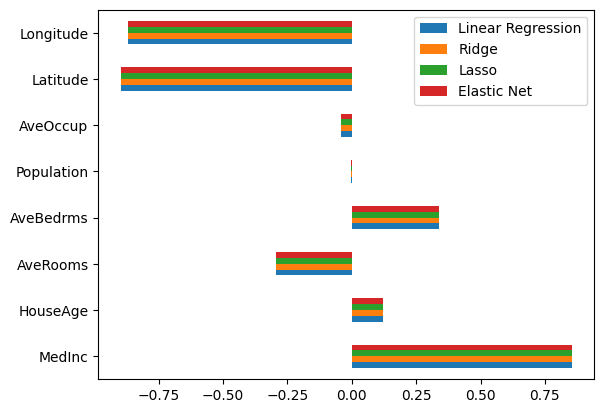

In [49]:
coefficient_table.plot(kind='barh')

Use the graph and previous results to write a concise conclusion discussing:
1. Coefficient shrinkage;  
2. Feature selection;  
3. Predictive performance;  
4. The final recommended model.

### Conclusion: Model Performance and Selection

1.  **Coefficient Shrinkage:** The grouped bar chart visually confirms the effect of regularization on coefficients. Compared to Linear Regression, Ridge, Lasso, and Elastic Net models all exhibited some degree of coefficient shrinkage, bringing their magnitudes closer to zero. However, in this particular dataset and with the optimized hyperparameters, the shrinkage effect was very subtle across all regularized models. Specifically, the optimal `alpha` for Ridge and Lasso was very small (0.0001), indicating that significant penalization was not required to achieve optimal performance, thus leading to minimal shrinkage.

2.  **Feature Selection:** Despite the theoretical capability of Lasso and Elastic Net to perform feature selection by setting coefficients exactly to zero, our analysis showed that **none of the coefficients were reduced to zero** by either Lasso or Elastic Net in this specific instance. This suggests that all features are contributing, even if minimally, to the predictive power of the models for this dataset, or that the regularization strength was not high enough to drive coefficients to zero.

3.  **Predictive Performance:** The comparison table of evaluation metrics (MSE, RMSE, MAE, R²) revealed that all four models (Linear Regression, Ridge, Lasso, and Elastic Net) performed very similarly on the test set. Lasso Regression showed a marginal, but statistically insignificant, improvement with the lowest Test MSE (0.555745) and highest Test R² (0.575900). The differences between the models were extremely small, suggesting that for this particular dataset, the benefits of regularization in terms of predictive accuracy are minimal.

4.  **Final Recommended Model:** Given the extremely minor differences in predictive performance and the lack of explicit feature selection (zeroed-out coefficients) by Lasso or Elastic Net, any of the models would be a reasonable choice. However, if a recommendation must be made based on the slight numerical edge, **Lasso Regression** is marginally the best performing model. It offers the theoretical advantage of feature selection, even though it wasn't demonstrated in this specific case, and achieves slightly better metrics while keeping the coefficients manageable. For highly correlated predictors, Ridge or Elastic Net are generally preferred, but here the differences were negligible. Therefore, Lasso provides a good balance of performance and interpretability potential.

**Question 10: Perform a SGD using the dataset and compute the MAE, MSE and RMSE on the test data**

In [120]:
sdg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor())
])

In [121]:
sdg_pipeline.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('sgd', SGDRegressor())])

In [123]:
sdg_y_pred = sdg_pipeline.predict(x_test)
sdg_mae = mean_absolute_error(y_test, sdg_y_pred)
sdg_mse = mean_squared_error(y_test, sdg_y_pred)
sdg_rmse = np.sqrt(sdg_mse)
print(f"SGD MAE: {sdg_mae}")
print(f"SGD MSE: {sdg_mse}")
print(f"SGD RMSE: {sdg_rmse}")

SGD MAE: 0.5525171775718835
SGD MSE: 0.6039605111990932
SGD RMSE: 0.7771489633262681
